In [23]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print(cv2.__version__)

4.13.0


In [24]:
from morph import *
help(mm.label0)
import inspect
print(inspect.getsource(mm.label0))
help(mm.label)
import inspect
print(inspect.getsource(mm.label))

Help on function label0 in module morph:

label0(f, b=array([[1, 1, 1],
       [1, 1, 1],
       [1, 1, 1]], dtype=uint8))
    This function will be calculate label of each connect component
    input:
      - f: input image
      - b: structure element
    output:
      - y: image with op

  @staticmethod
  def label0(f,b=np.ones((3,3),dtype='uint8')):
    """This function will be calculate label of each connect component
    input:
      - f: input image
      - b: structure element
    output:
      - y: image with op
    """
    h,w = f.shape
    bh, bw = b.shape

    g = np.zeros(f.shape).astype(int)
    cor = 1
    pilha = []
    for x in range(h):
     for y in range(w):

      if (f[x,y]) and not g[x,y]: # buscar pixel de objeto não pintado

        pilha.append([x,y]) # colocar na pilha pixel p=[x,y]

        while pilha: # laço para pintar todos os pixel de cada objeto com cor
          i,j=pilha.pop() # retirar da pilha pixel q=[i,j]
          g[i,j] = cor

          # para 

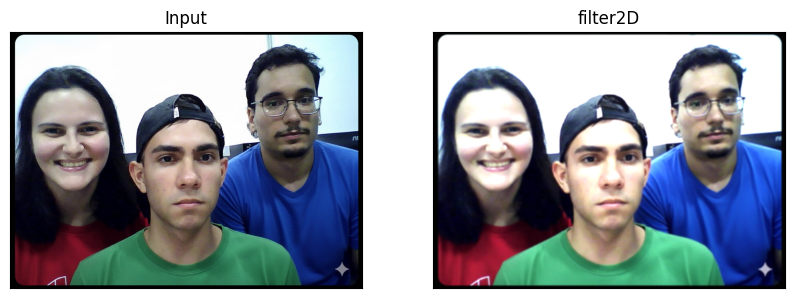

In [40]:
img1 = cv2.imread('testeI.jpeg')
img = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
kernel = np.ones((6,6),np.float32)/25

filter2D = cv2.filter2D(img,-1,kernel)

blur = cv2.blur(img,(5,5))

gaussianBlur = cv2.GaussianBlur(img,(5,5),0)

median = cv2.medianBlur(img,5)

bilateralFilter = cv2.bilateralFilter(img,13,99,99)

plt.figure(figsize=(10,6))
plt.subplot(121),plt.imshow(img,"gray"),plt.title('Input')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(filter2D,"gray"),plt.title('filter2D')
plt.xticks([]), plt.yticks([])
plt.show()

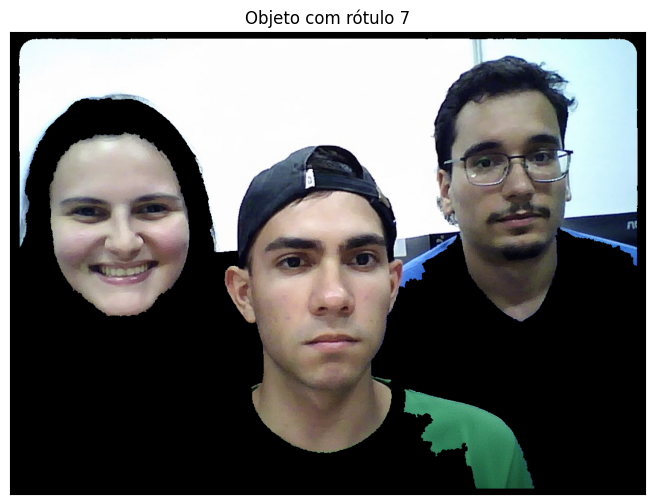

In [42]:
# Utilize os rótulos!!!
output_img = np.zeros_like(img)
output_img[markers == 1] = img[markers == 1]

plt.figure(figsize=(10,6))
plt.imshow(output_img)
plt.xticks([]), plt.yticks([])
plt.title('Objeto com rótulo 7')
plt.show()

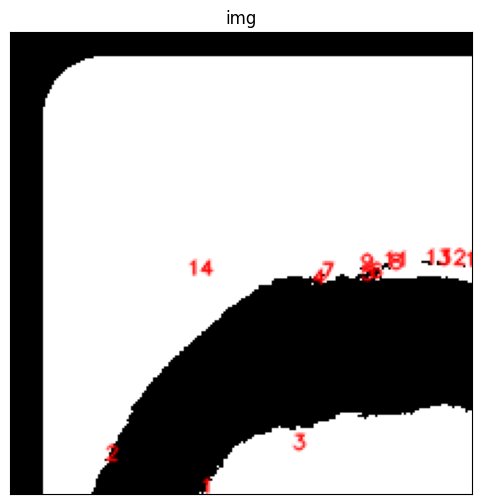

In [32]:
# mude o padrao aqui
padrao = cv2.RETR_LIST
font = cv2.FONT_HERSHEY_SIMPLEX

f = cv2.imread('testeI.jpeg',0)
img_teste = f[0:210,0:210]

T,img_teste = cv2.threshold(img_teste,0,255,cv2.THRESH_OTSU) #<<<<<<<<<<

img_canny = cv2.Canny(img_teste, 100, 200)
cont, _ = cv2.findContours(img_teste.copy(), padrao, cv2.CHAIN_APPROX_SIMPLE)

color_img = cv2.cvtColor(img_teste, cv2.COLOR_GRAY2RGB)

for k,c in enumerate(cont):
    x,y,w,h = cv2.boundingRect(c)
    cv2.putText(color_img, str(k+1),(x+w//3, y+h//2), font, 0.3,(255,0,0),1,cv2.LINE_AA)

plt.figure(figsize=(10,6))
plt.imshow(color_img,"gray"),plt.title('img')
plt.xticks([]), plt.yticks([])
plt.show()